In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import dictys
from dictys.net import stat
import joblib
import pickle
from scipy.stats import median_abs_deviation, hypergeom
import math

In [2]:
from utils_custom import *
from episodic_dynamics import *
from pseudotime_curves import *

In [3]:
# Paths
#dictys_dynamic_object_path = "/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/dynamic.h5"
dictys_dynamic_object_path = "/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/dynamic.h5"
output_folder = '/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/episodic_grns/84_percentile'
latent_factor_folder = '/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/latent_factors'
lf_blimp1_file = f"{latent_factor_folder}/feature_list_Z5_PRDM1_KO.txt"
lf_irf4_file = f"{latent_factor_folder}/feature_list_Z4_IRF4_KO.txt"

In [4]:
lf_blimp1 = pd.read_csv(lf_blimp1_file, sep='\t')['names'].tolist()
lf_irf4 = pd.read_csv(lf_irf4_file, sep='\t')['names'].tolist()

In [5]:
lf_geneset = lf_blimp1

# Load episodic GRNs
### For analyzing dynamic TF activities

In [6]:
tfs_of_interest     = ['BCL6']
targets_of_interest = lf_geneset

episodic_grn_edges_subset = get_episodic_grn_subset(
    output_folder       = output_folder,
    tfs_of_interest     = tfs_of_interest,
    targets_of_interest = targets_of_interest,
    value_col           = 'avg_force'
)

display(episodic_grn_edges_subset)

,episode,1,2,3,4,5,6,7,8
TF,target,,,,,,,,


In [11]:
# save the episodic_grn_edges_subset df to a csv file (with the index as the first column)
episodic_grn_edges_subset.to_csv(os.path.join(output_folder, 'episodic_grn_subset_60_IRF4_KO.csv'), index=True)

#### Construct/Enrich for LF activity in one episode

In [ ]:
run_episodic_construction(
    episode_idx=1,
    dictys_dynamic_object_path=dictys_dynamic_object_path,
    output_folder=output_folder,
    trajectory_range=(0, 1),
    num_points=40, # 8 episodes
    time_slice_start=0, # 0 indexed
    time_slice_end=5 # last index is excluded
)

In [ ]:
run_episodic_enrichment(
    episode_idx=4,
    dictys_dynamic_object_path=dictys_dynamic_object_path,
    output_folder=output_folder,
    latent_factor_folder=latent_factor_folder,
    trajectory_range=(1, 3),
    num_points=40,
    time_slice_start=15,
    time_slice_end=20, # last index is excluded
    lf_genes=lf_geneset
)

### Un-parallelized version

In [6]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file(dictys_dynamic_object_path)

### Expression dynamics

In [6]:
pseudotime_object = SmoothedCurvesGRN(dictys_dynamic_object,
    trajectory_range=(1,3),
    num_points=40,
    dist=0.001,
    sparsity=0.01,
    mode="expression")

In [7]:
# get lcpm chars for these genes
lcpm_dcurve, dtime = pseudotime_object.get_smoothed_curves(mode='expression')
# remove genes with names starting with ZNF and ZBTB
lcpm_dcurve = lcpm_dcurve[~lcpm_dcurve.index.str.startswith('ZNF') & ~lcpm_dcurve.index.str.startswith('ZBTB')]
# get lcpm chars for these genes
#lcpm_dcurve_gc, dtime_gc = compute_expression_regulation_curves(dictys_dynamic_object, start=0, stop=3, num=20, dist=0.001, mode="expression")
# slice the dcurve for the lf genes using gene names which are indices in pandas df
display(lcpm_dcurve.head())

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
A1BG,4.155221,4.170672,4.186634,4.203052,4.219861,4.236983,4.254330,4.271800,4.289273,4.306614,...,4.165388,4.147355,4.132847,4.121469,4.112746,4.106199,4.101390,4.097944,4.095549,4.093957
A1BG-AS1,3.620198,3.623879,3.627706,3.631671,3.635768,3.639987,3.644317,3.648745,3.653257,3.657838,...,3.744351,3.746146,3.747664,3.748939,3.750005,3.750892,3.751625,3.752227,3.752714,3.753101
AAAS,4.605135,4.601931,4.598233,4.594046,4.589384,4.584273,4.578746,4.572852,4.566651,4.560224,...,4.722776,4.735847,4.746097,4.753841,4.759452,4.763303,4.765736,4.767046,4.767476,4.767224
AACS,4.004986,4.036881,4.069677,4.103297,4.137661,4.172683,4.208282,4.244379,4.280905,4.317806,...,5.104201,5.116823,5.126365,5.133484,5.138752,5.142634,5.145495,5.147611,5.149186,5.150371
AAGAB,5.743944,5.745945,5.747973,5.750020,5.752081,5.754151,5.756227,5.758306,5.760391,5.762487,...,5.925421,5.935478,5.944243,5.951820,5.958349,5.963979,5.968854,5.973103,5.976835,5.980144


### Regulation dynamics


In [8]:
pts, fsmooth = dictys_dynamic_object.linspace(1,3,40,0.001)
stat1_net = fsmooth(stat.net(dictys_dynamic_object)) #varname=w_in loads total effect network
stat1_netbin = stat.fbinarize(stat1_net,sparsity=0.01)
stat1_x=stat.pseudotime(dictys_dynamic_object,pts)
dtime = pd.Series(stat1_x.compute(pts)[0])

### Build episode specific GRN (transient state specific)

In [91]:
# pts is a dictys traj object
dnetbin = stat1_netbin.compute(pts)
dnetbin_episode = dnetbin[:, :, 35:40] #5 timepoints, excludes the last one

In [92]:
# compute the weighted network
dnet = stat1_net.compute(pts)
dnet_episode = dnet[:, :, 35:40]
display(dnet_episode)

array([[[-7.68027397e-02, -7.86555274e-02, -8.02257754e-02,
         -8.15711148e-02, -8.27383602e-02],
        [-5.67164702e-02, -5.77812528e-02, -5.87774974e-02,
         -5.97179033e-02, -6.06127213e-02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 1.23257120e-01,  1.23707930e-01,  1.24197323e-01,
          1.24712617e-01,  1.25243133e-01],
        [ 7.43273459e-02,  7.54473656e-02,  7.63524889e-02,
          7.70831120e-02,  7.76723756e-02]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.0000000

### Filter episodic GRN edges which are significantly non-zero across time points and are direction invariant

In [93]:
###### Get the tf and target names #####
# Create reverse mapping: index -> gene_name
ndict = dictys_dynamic_object.ndict
index_to_gene = {idx: name for name, idx in ndict.items()}
target_names = [index_to_gene[idx] for idx in range(dnetbin_episode.shape[1])]
# Get TF_gene_indices from TFs_to_keep_indices using nids[0]
tf_gene_indices = [dictys_dynamic_object.nids[0][tf_idx] for tf_idx in range(dnetbin_episode.shape[0])]
tf_names = [index_to_gene[idx] for idx in tf_gene_indices]
print(len(target_names))
print(len(tf_names))

11907
551


In [94]:
###### Create multi-index tuples (all combinations of TF-target pairs) ######
index_tuples = [(tf, target) for tf in tf_names for target in target_names]
multi_index = pd.MultiIndex.from_tuples(index_tuples, names=['TF', 'Target'])
# Reshape the subnetworks array to 2D (pairs × time points)
n_tfs, n_targets, n_times = dnet_episode.shape
reshaped_data = dnet_episode.reshape(-1, n_times)
# Create DataFrame with multi-index
episode_beta_dcurve = pd.DataFrame(
    reshaped_data,
    index=multi_index,
    columns=[f'time_{i}' for i in range(n_times)]
)
# drop rows that are all 0
episode_beta_dcurve = episode_beta_dcurve[episode_beta_dcurve.sum(axis=1) != 0]
# the number of edges here remain the same between episodes, indicating that exact 0 are the edges that don't have atac-seq basis
display(episode_beta_dcurve.head())
display(episode_beta_dcurve.shape)

time_0    time_1    time_2        time_3        time_4
TF  Target                                                            
AHR A1BG     -0.076803 -0.078656 -0.080226 -8.157111e-02 -8.273836e-02
    A1BG-AS1 -0.056716 -0.057781 -0.058777 -5.971790e-02 -6.061272e-02
    AAGAB     0.000003  0.000002  0.000001  8.382825e-07  5.431128e-07
    AAK1      0.020383  0.019385  0.018621  1.803558e-02  1.758554e-02
    AAMDC     0.000118  0.000083  0.000059  4.092222e-05  2.855463e-05

(1471590, 5)

In [95]:
###### Filtering the global episodic GRN for retaining significantly non-zero and direction invariant edges ######
filtered_edges = filter_edges_by_significance_and_direction(
    episode_beta_dcurve,
    min_nonzero_timepoints=3,
    alpha=0.05,
    min_observations=3,
    check_direction_invariance=True,  # Enable direction invariance check
    n_processes=60,
    chunk_size=8000,
    save_intermediate=False,
    intermediate_path=output_folder
)
    
print(f"\nFinal shape: {filtered_edges.shape}")

Processing 1,471,590 rows using 60 processes...
Chunk size: 8,000 rows
Direction invariance check: Enabled
Time columns: ['time_0', 'time_1', 'time_2', 'time_3', 'time_4']
Creating index chunks...
Created 184 chunks of indices


Processing chunks: 100%|██████████| 184/184 [00:41<00:00,  4.41it/s]


Processing completed in 44.97 seconds
Sorting results...
Creating result DataFrame...

Final shape: (1449287, 6)


In [96]:
# load episode parquet file into pandas
#filtered_edges = pd.read_parquet('/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/dictys_outs/actb1_added_v2/output/intermediate_tmp_files/filtered_edges_significant_invariant_PB_ep4.parquet')
# remove TFs starting with ZNF or ZBTB
filtered_edges = filtered_edges[~filtered_edges.index.get_level_values(0).str.startswith('ZNF') & ~filtered_edges.index.get_level_values(0).str.startswith('ZBTB')]
display(filtered_edges)

time_0    time_1    time_2        time_3        time_4  \
TF      Target                                                               
AHR     A1BG     -0.076803 -0.078656 -0.080226 -8.157111e-02 -8.273836e-02   
        A1BG-AS1 -0.056716 -0.057781 -0.058777 -5.971790e-02 -6.061272e-02   
        AAGAB     0.000003  0.000002  0.000001  8.382825e-07  5.431128e-07   
        AAK1      0.020383  0.019385  0.018621  1.803558e-02  1.758554e-02   
        AAMDC     0.000118  0.000083  0.000059  4.092222e-05  2.855463e-05   
...                    ...       ...       ...           ...           ...   
ZSCAN30 ZXDC      0.002677  0.002775  0.002866  2.951044e-03  3.031066e-03   
        ZYG11B    0.003598  0.003760  0.003898  4.018011e-03  4.123597e-03   
        ZZEF1    -0.000007 -0.000005 -0.000003 -1.949877e-06 -1.253799e-06   
ZSCAN9  AGFG1     0.010662  0.010762  0.010822  1.084892e-02  1.085007e-02   
        MFF       0.005871  0.005926  0.005959  5.974424e-03  5.975408e-03   

                       p_value  
TF      Target                  
AHR     A1BG      1.778287e-07  
        A1BG-AS1  1.131998e-07  
        AAGAB     2.598741e-02  
        AAK1      2.915095e-06  
        AAMDC     1.466529e-02  
...                        ...  
ZSCAN30 ZXDC      1.365292e-06  
        ZYG11B    1.970581e-06  
        ZZEF1     2.734373e-02  
ZSCAN9  AGFG1     7.045065e-10  
        MFF       7.370410e-10  

[970797 rows x 6 columns]

In [97]:
# drop edges with p_value > 0.01
filtered_edges_p001 = filtered_edges[filtered_edges['p_value'] < 0.001]
display(filtered_edges_p001.head())
display(filtered_edges_p001.shape)

time_0    time_1    time_2    time_3    time_4       p_value
TF  Target                                                                  
AHR A1BG     -0.076803 -0.078656 -0.080226 -0.081571 -0.082738  1.778287e-07
    A1BG-AS1 -0.056716 -0.057781 -0.058777 -0.059718 -0.060613  1.131998e-07
    AAK1      0.020383  0.019385  0.018621  0.018036  0.017586  2.915095e-06
    AAMP      0.058639  0.060031  0.061299  0.062463  0.063541  2.406762e-07
    AARS2     0.088741  0.089963  0.090932  0.091703  0.092322  1.439202e-08

(663662, 6)

### Get TF forces for the episode & State

In [98]:
###### CHANGE STATE HERE ######
tf_lcpm_values = lcpm_dcurve.loc[filtered_edges_p001.index.get_level_values(0).unique()]
display(tf_lcpm_values.shape)
###### CHANGE EPISODE HERE ######
tf_lcpm_episode = tf_lcpm_values.iloc[:, 35:40]

# Adaptive column renaming to match beta curves
beta_time_cols = [col for col in filtered_edges_p001.columns if col.startswith('time_')]
n_time_cols = len(beta_time_cols)

# Rename TF expression columns to match beta curves format
tf_lcpm_episode.columns = beta_time_cols[:n_time_cols]
display(tf_lcpm_episode)

(322, 40)

,time_0,time_1,time_2,time_3,time_4
TF,,,,,
AHR,8.034156,8.044499,8.052512,8.058718,8.063526
ARID3A,7.010609,7.004856,6.999229,6.993801,6.988604
ARID3B,6.973890,6.977542,6.979879,6.981277,6.982013
ARID5A,7.063546,7.068766,7.072391,7.074815,7.076337
ARID5B,8.992730,8.995771,8.999048,9.002494,9.006056
...,...,...,...,...,...
ZKSCAN7,0.957745,0.951491,0.946463,0.942383,0.939037
ZSCAN26,3.003774,3.009430,3.014170,3.018199,3.021679
ZSCAN29,3.700937,3.707809,3.713433,3.718044,3.721833


In [99]:
# Prepare beta curves (only time columns)
beta_curves_for_force = filtered_edges_p001.drop('p_value', axis=1)

print("Starting parallel force calculation...")
print(f"Input beta curves shape: {beta_curves_for_force.shape}")
print(f"TF expression shape: {tf_lcpm_episode.shape}")

# Calculate forces in parallel
force_curves = calculate_force_curves_parallel(
    beta_curves=beta_curves_for_force,
    tf_expression=tf_lcpm_episode,
    n_processes=20,  # Adjust based on your system
    chunk_size=30000,  # Adjust based on available memory
    epsilon=1e-10,
    save_intermediate=False
)

print(f"Force calculation completed!")
print(f"Output shape: {force_curves.shape}")
# Display sample results
display(force_curves.head())

Starting parallel force calculation...
Input beta curves shape: (663662, 5)
TF expression shape: (322, 5)
Processing 663,662 edges using 20 processes...
Chunk size: 30,000 rows
Time columns: ['time_0', 'time_1', 'time_2', 'time_3', 'time_4']
Beta curves shape: (663662, 5)
TF expression shape: (322, 5)
Created 22 chunks
Chunk sizes: [30167, 30167, 30167, 30167, 30167]...


Processing chunks: 100%|██████████| 22/22 [00:02<00:00, 10.99it/s]


Processing completed in 3.09 seconds
Combining results...
Final shape: (663662, 5)
Force calculation completed!
Output shape: (663662, 5)


time_0    time_1    time_2    time_3    time_4
TF  Target                                                    
AHR A1BG     -0.628756 -0.634795 -0.639835 -0.644100 -0.647763
    A1BG-AS1 -0.551188 -0.555218 -0.558977 -0.562518 -0.565880
    AAK1      0.353412  0.345518  0.339305  0.334437  0.330622
    AAMP      0.559225  0.564504  0.569267  0.573606  0.577593
    AARS2     0.669474  0.672928  0.675608  0.677698  0.679342

#### Get the average force over the episode

In [100]:
# Calculate average force over the 5 time points
avg_force = force_curves.mean(axis=1)
print(f"Average force shape: {avg_force.shape}")
# Convert to DataFrame with proper column name
avg_force_df = avg_force.to_frame(name='avg_force')
display(avg_force_df.head())

Average force shape: (663662,)


avg_force
TF  Target             
AHR A1BG      -0.639050
    A1BG-AS1  -0.558756
    AAK1       0.340659
    AAMP       0.568839
    AARS2      0.675010

#### Load episodic forces

In [17]:
episode_idx = 6
avg_force_df = pd.read_parquet(os.path.join(output_folder, f'avg_force_episode_{episode_idx}.parquet'))
display(avg_force_df.head())


avg_force
TF  Target                  
Ahr 1110008L16Rik   0.534597
    1110019D14Rik   0.722170
    1700055D18Rik   0.663963
    1810013L24Rik  -0.918892
    1810043G02Rik  -0.874085

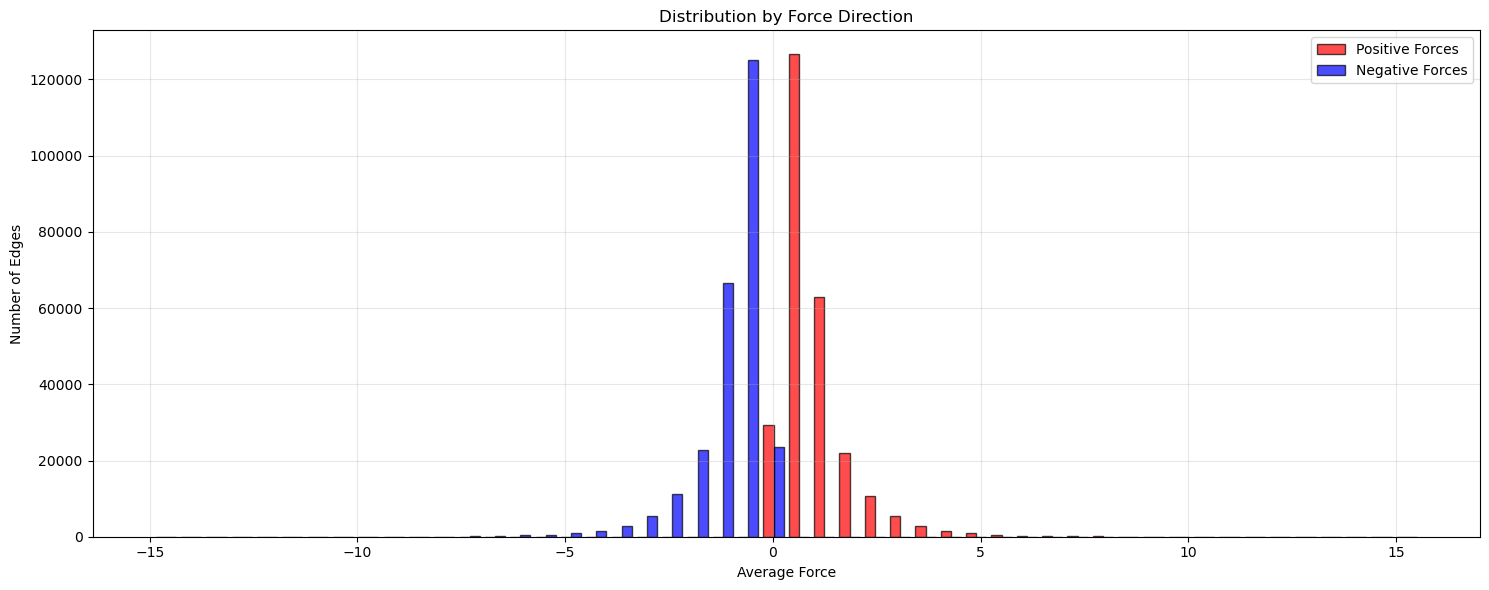

In [18]:
# Plot distribution
fig, axes = plt.subplots(1, 1, figsize=(15, 6))

# Separate positive and negative forces
positive_forces = avg_force_df[avg_force_df['avg_force'] > 0].values.flatten()
negative_forces = avg_force_df[avg_force_df['avg_force'] < 0].values.flatten()

axes.hist([positive_forces, negative_forces], bins=50, alpha=0.7, 
              color=['red', 'blue'], label=['Positive Forces', 'Negative Forces'], edgecolor='black')
axes.set_xlabel('Average Force')
axes.set_ylabel('Number of Edges')
axes.set_title('Distribution by Force Direction')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
# save the plot
plt.savefig(os.path.join('/ocean/projects/cis240075p/asachan/datasets/B_Cell/T_cell/outs/dictys/rbpj_ntc/output/figs', 'force_distribution_ep6_rbpj_ntc.pdf'))
plt.show()

In [ ]:
import numpy as np
import pandas as pd

if len(positive_forces) > 0:
    pos_threshold = np.percentile(positive_forces, 98)
    top_pos_edges = positive_forces[positive_forces >= pos_threshold]
else:
    top_pos_edges = pd.Series(dtype=avg_force.dtype)

if len(negative_forces) > 0:
    neg_threshold = np.percentile(negative_forces, 0.5)
    top_neg_edges = negative_forces[negative_forces <= neg_threshold]
else:
    top_neg_edges = pd.Series(dtype=avg_force.dtype)

# Combine into a DataFrame
episodic_grn_edges = pd.concat([top_pos_edges, top_neg_edges]).to_frame(name='avg_force')

# Optionally, sort by force value (descending for positive, ascending for negative)
episodic_grn_edges = episodic_grn_edges.sort_values(by='avg_force', ascending=False)

# Display or use as needed
print(episodic_grn_edges)
print(f"Number of positive edges: {len(top_pos_edges)}")
print(f"Number of negative edges: {len(top_neg_edges)}")
print(f"Total selected edges: {len(episodic_grn_edges)}")
# display the unique tf and target numbers
display(len(episodic_grn_edges.index.get_level_values(0).unique()))
display(len(episodic_grn_edges.index.get_level_values(1).unique()))

#### Select the top k% of edges to build the episodic GRN

## Get the TFs acting on LF genes

In [ ]:
# load LF files 
z11_file = '/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/latent_factors/feature_list_Z11_GC_PB.txt'
z3_file = '/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/latent_factors/feature_list_Z3_GC_PB.txt'
z_prdm1_ko = "/ocean/projects/cis240075p/asachan/datasets/B_Cell/multiome_1st_donor_UPMC_aggr/other_files/latent_factors/feature_list_Z5_PRDM1_KO.txt"
# load into a list of gene names 
z11 = pd.read_csv(z11_file, sep='\t', header=0)
z3 = pd.read_csv(z3_file, sep='\t', header=0)
z_prdm1_ko = pd.read_csv(z_prdm1_ko, sep='\t', header=0)
# remove HLA- genes
z11 = z11[~z11['names'].str.contains('HLA-')]
z3 = z3[~z3['names'].str.contains('HLA-')]
z_prdm1_ko = z_prdm1_ko[~z_prdm1_ko['names'].str.contains('HLA-')]

In [ ]:
# get the gene names 
z11_genes = z11['names'].tolist()
z3_genes = z3['names'].tolist()
z_prdm1_ko_genes = z_prdm1_ko['names'].tolist()
# create a list of all lf genes 
#lf_genes = list(set(z11_genes + z3_genes))
lf_genes = list(set(z_prdm1_ko_genes))
lf_in_object = check_if_gene_in_ndict(dictys_dynamic_object, lf_genes, return_index=True)
print(f"Found {len(lf_in_object['present'])} genes")
print(f"Missing {len(lf_in_object['missing'])} genes")
print("Indices:", lf_in_object['indices'])

#### Get the enrichment (over representation) of LF genes in TF regulons

In [ ]:
# add a boolean column indicating if the target is a lf gene in the episodic grn df
episodic_grn_edges['is_in_lf'] = episodic_grn_edges.index.get_level_values(1).isin(lf_genes)
# get the number of genes in the episodic grn edges
target_genes_in_episodic_grn = episodic_grn_edges.index.get_level_values(1).unique()
display("Number of targets in episodic grn: ", len(target_genes_in_episodic_grn))
# get the number of lf_genes in the episodic grn edges
lf_in_episodic_grn = episodic_grn_edges[episodic_grn_edges['is_in_lf']]
display(lf_in_episodic_grn.head())
# get the unique LF genes active in the lf_in_episodic_grn df
lf_genes_active_in_episode = lf_in_episodic_grn.index.get_level_values(1).unique()
display("Number of LF genes active in episode: ", len(lf_genes_active_in_episode))
tfs_acting_on_lf = lf_in_episodic_grn.index.get_level_values(0).unique()
display("TFs acting on LF genes: ", tfs_acting_on_lf, len(tfs_acting_on_lf))
# take the tfs in the lf_in_episodic_grn df and subset the episodic_grn_edges df to only include these tfs
episodic_grn_edges_subset = episodic_grn_edges[episodic_grn_edges.index.get_level_values(0).isin(lf_in_episodic_grn.index.get_level_values(0))]
display(episodic_grn_edges_subset.head())
display(episodic_grn_edges_subset.shape)

In [ ]:
episodic_enrichment_df = calculate_tf_episodic_enrichment(episodic_grn_edges_subset, 
                                       len(lf_genes_active_in_episode), 
                                       len(target_genes_in_episodic_grn))
# sort the episodic_enrichment_df_p005 by enrichment_score in descending order
episodic_enrichment_df_sorted = episodic_enrichment_df.sort_values(by='enrichment_score', ascending=False)
# filter the episodic_enrichment_df to only include tfs with a p_value < threshold
episodic_enrichment_df_p005 = episodic_enrichment_df_sorted[episodic_enrichment_df_sorted['p_value'] < 0.05]
display(episodic_enrichment_df_p005)

In [ ]:
# save the episodic_enrichment_df_p005_sorted df to a csv file
episodic_enrichment_df_sorted.to_csv(os.path.join(output_folder, 'enrichment_ep1_blimp_ko.csv'), index=False)